**02 – Descriptive Statistics & Core Visualizations**

Provide a first empirical picture of blocking behavior on Bluesky:
- How common is blocking?
- Who blocks, and who gets blocked?
- How much blocking is list-based vs direct?
- What do the distributions look like?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)

In [3]:
blocks = pd.read_parquet("blocks.parquet")
list_blocks = pd.read_parquet("list_blocks.parquet")

Total blocks

In [4]:
total_direct_blocks = len(blocks)
total_list_blocks = len(list_blocks)

total_direct_blocks, total_list_blocks

(78287665, 2242503)

Share of list-based blocking

In [5]:
share_list = total_list_blocks / (total_direct_blocks + total_list_blocks)
share_list

0.02784674434058054

Temporal dynamics of blocking

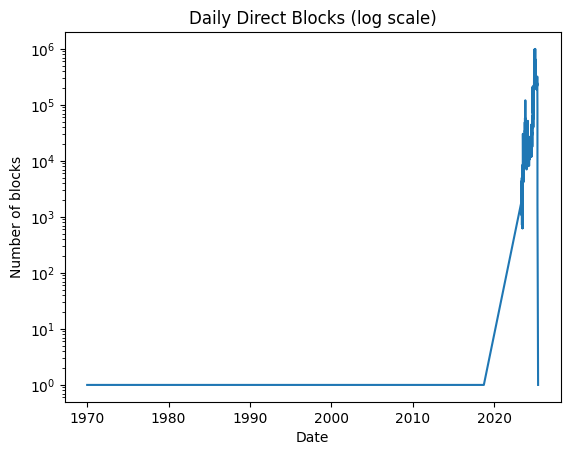

In [13]:
blocks['created_date'] = pd.to_datetime(blocks['created_date'], errors='coerce')
list_blocks['created_date'] = pd.to_datetime(list_blocks['created_date'], errors='coerce')

daily_blocks = (
blocks
.groupby(blocks['created_date'].dt.date)
.size()
)
plt.figure()
daily_blocks.plot(logy=True)
plt.title("Daily Direct Blocks (log scale)")
plt.xlabel("Date")
plt.ylabel("Number of blocks")
plt.show()

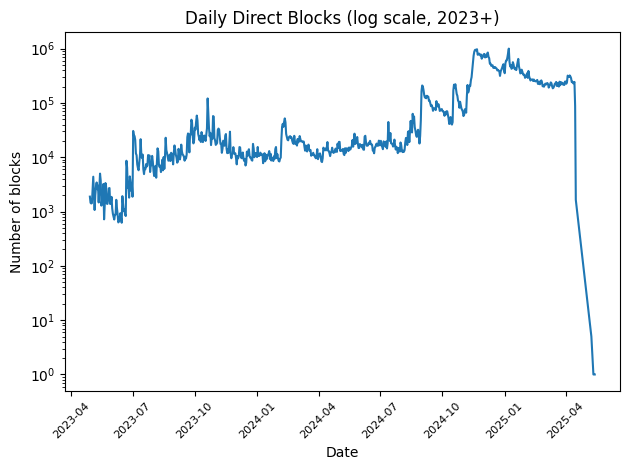

In [19]:
# keep only blocks from 2023 onwards
blocks_2023 = blocks[blocks['created_date'].dt.year >= 2023]

daily_blocks_2023 = (
    blocks_2023
    .groupby(blocks_2023['created_date'].dt.date)
    .size()
)

plt.figure()
daily_blocks_2023.plot(logy=True)
plt.title("Daily Direct Blocks (log scale, 2023+)")
plt.xlabel("Date")
plt.ylabel("Number of blocks")
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()


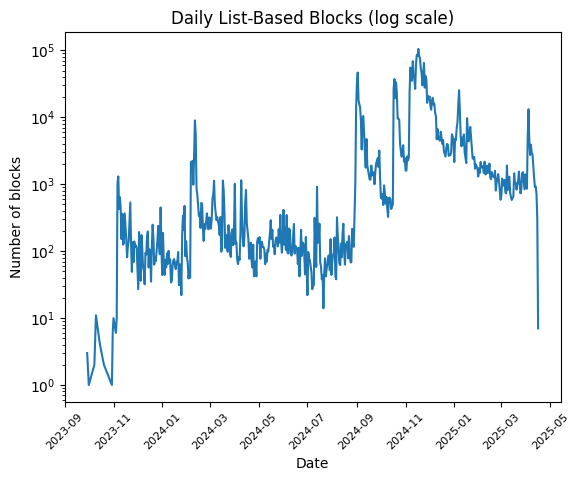

In [20]:
daily_list_blocks = (
    list_blocks
    .groupby(list_blocks['created_date'].dt.date)
    .size()
)

plt.figure()
daily_list_blocks.plot(logy=True)
plt.title("Daily List-Based Blocks (log scale)")
plt.xlabel("Date")
plt.xticks(rotation=45, fontsize=8)
plt.ylabel("Number of blocks")
plt.show()

Who blocks?

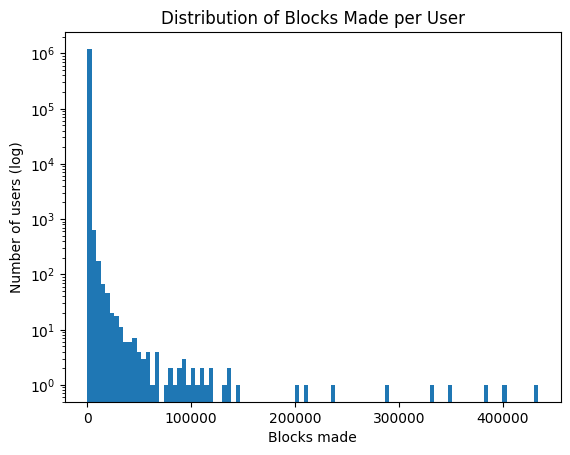

In [8]:
blocks_per_user = blocks['did_id'].value_counts()
plt.figure()
plt.hist(blocks_per_user, bins=100, log=True)
plt.title("Distribution of Blocks Made per User")
plt.xlabel("Blocks made")
plt.ylabel("Number of users (log)")
plt.show()

Who gets blocked?

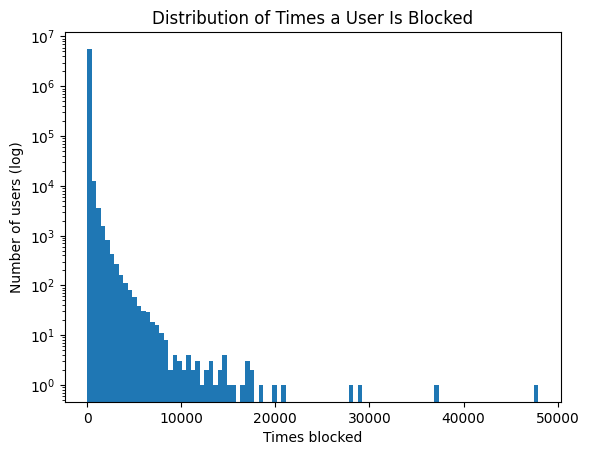

In [9]:
blocked_counts = blocks['subject_did_id'].value_counts()
plt.figure()
plt.hist(blocked_counts, bins=100, log=True)
plt.title("Distribution of Times a User Is Blocked")
plt.xlabel("Times blocked")
plt.ylabel("Number of users (log)")
plt.show()

Inequality in blocking behavior

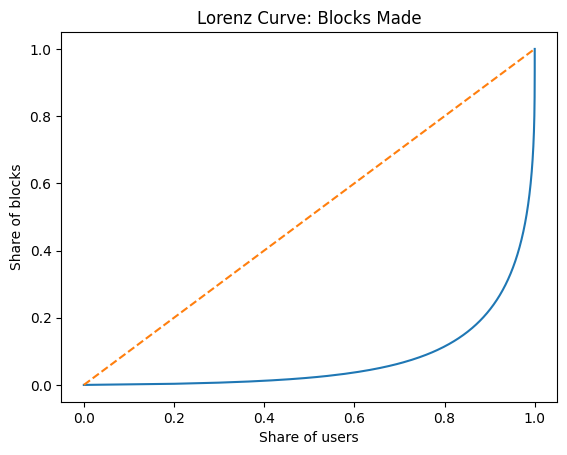

In [10]:
x = np.sort(blocks_per_user.values)
cum = np.cumsum(x) / np.sum(x)

plt.figure()
plt.plot(np.linspace(0,1,len(cum)), cum)
plt.plot([0,1],[0,1], linestyle='--')
plt.title("Lorenz Curve: Blocks Made")
plt.xlabel("Share of users")
plt.ylabel("Share of blocks")
plt.show()

Direct vs list based blocking

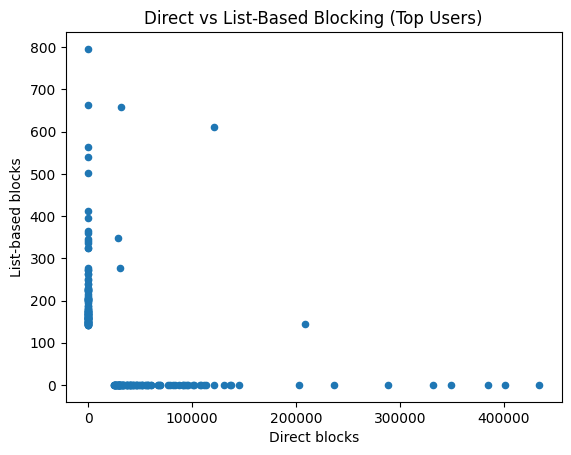

In [11]:
top_direct_blockers = blocks['did_id'].value_counts().head(100)
top_list_blockers = list_blocks['did_id'].value_counts().head(100)

comparison = pd.DataFrame({
    'direct_blocks': top_direct_blockers,
    'list_blocks': top_list_blockers
}).fillna(0)

comparison.plot(kind='scatter', x='direct_blocks', y='list_blocks')
plt.title("Direct vs List-Based Blocking (Top Users)")
plt.xlabel("Direct blocks")
plt.ylabel("List-based blocks")
plt.show()